For this project we have chosen a dataset for tide prediction. It contains data about the water level every ten minutes in diferent stations of Ireland. The Water_Level_ODM vairable that is the one we are using, is just a more clean and standarized column prepared for the operations that comes directly with the dataset for its easier implementation.
It contains data from 2017 to 2020. Our first goal is to check if tides are predictable, as nature is difficult to predict.
Second, is to be able to predict tides for the next week, for ships to known when it is dangerous for them to navigate. 
Also, we want to try the model facebook prophet as it can also predict occurences not seen before in the data, tsunamic or any other irregularities.
But that can be difficult taking into account we are analyzing data from Ireland

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import kagglehub
import os

In [30]:
np.random.seed(42)

In [31]:
# We start by downloading the dataset
path = kagglehub.dataset_download("arjunbhaybhang/marine-institute-tide-prediction-dataset")

print("Path to dataset files:", path)

files_in_directory = os.listdir(path)
print("Archivos en el directorio:", files_in_directory)

csv_file_path = os.path.join(path, 'Tide Prediction.csv')

data = pd.read_csv(csv_file_path)
data = data.iloc[1:]#The first row of the dataset is titles.

print(data.head())

Path to dataset files: C:\Users\angel\.cache\kagglehub\datasets\arjunbhaybhang\marine-institute-tide-prediction-dataset\versions\1
Archivos en el directorio: ['Tide Prediction.csv']


C:\Users\angel\AppData\Local\Temp\ipykernel_14596\4283588312.py:11: DtypeWarning: Columns (1,2,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file_path)


                   time   longitude  latitude               stationID  \
1  2017-01-01T00:10:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
2  2017-01-01T00:20:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
3  2017-01-01T00:30:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
4  2017-01-01T00:40:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
5  2017-01-01T00:50:00Z  -10.101596  53.95219  Achill_Island_MODELLED   

  Water_Level Water_Level_ODM  
1        1.34           -1.23  
2         1.3           -1.27  
3        1.26           -1.31  
4        1.23           -1.34  
5        1.22           -1.35  


## Quick data cleaning

In [32]:
print(data.isna().sum())

time               0
longitude          0
latitude           0
stationID          0
Water_Level        0
Water_Level_ODM    0
dtype: int64


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6885393 entries, 1 to 6885393
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   time             object
 1   longitude        object
 2   latitude         object
 3   stationID        object
 4   Water_Level      object
 5   Water_Level_ODM  object
dtypes: object(6)
memory usage: 315.2+ MB


In [34]:
#We parse the diferent columns to their respective data type
data['time'] = pd.to_datetime(data['time'])
data['longitude'] = pd.to_numeric(data['longitude'])
data['latitude'] = pd.to_numeric(data['latitude'])
data['Water_Level'] = pd.to_numeric(data['Water_Level'])
data['Water_Level_ODM'] = pd.to_numeric(data['Water_Level_ODM'])

In [35]:
data.head()

,time,longitude,latitude,stationID,Water_Level,Water_Level_ODM
1,2017-01-01 00:10:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.34,-1.23
2,2017-01-01 00:20:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.30,-1.27
3,2017-01-01 00:30:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.26,-1.31
4,2017-01-01 00:40:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.23,-1.34
5,2017-01-01 00:50:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.22,-1.35


In [36]:
data['stationID'].unique()

array(['Achill_Island_MODELLED', 'Aranmore', 'Arklow_MODELLED',
       'Ballycotton', 'Ballyglass', 'Bray_Harbour_MODELLED',
       'Carrigaholt_MODELLED', 'Castletownbere', 'Clare_Island_MODELLED',
       'Crosshaven_MODELLED', 'Dingle_Harbour_MODELLED', 'Dublin_Port',
       'Dundalk', 'Dungarvan_MODELLED', 'Dunmore_East', 'Fenit_MODELLED',
       'Galway_Port', 'Howth', 'Inishmore', 'Killary_Harbour_MODELLED',
       'Killybegs', 'Kinsale_MODELLED', 'Kish_Bank_Lighthouse',
       'Lahinch_MODELLED', 'Letterfrack_MODELLED', 'Malin_Head',
       'Rosslare_Port_MODELLED', 'Skerries', 'Sligo',
       'Tory_Island_MODELLED', 'Union_Hall_MODELLED', 'Wexford',
       'Wicklow_MODELLED'], dtype=object)

In [37]:
# Since our dataset is really big, we're only going to take data from an specific port
# Lets take only from Dingle_Harbour_MODELLED

data_located = data[data['stationID'] == 'Dingle_Harbour_MODELLED']

## Data Visualization

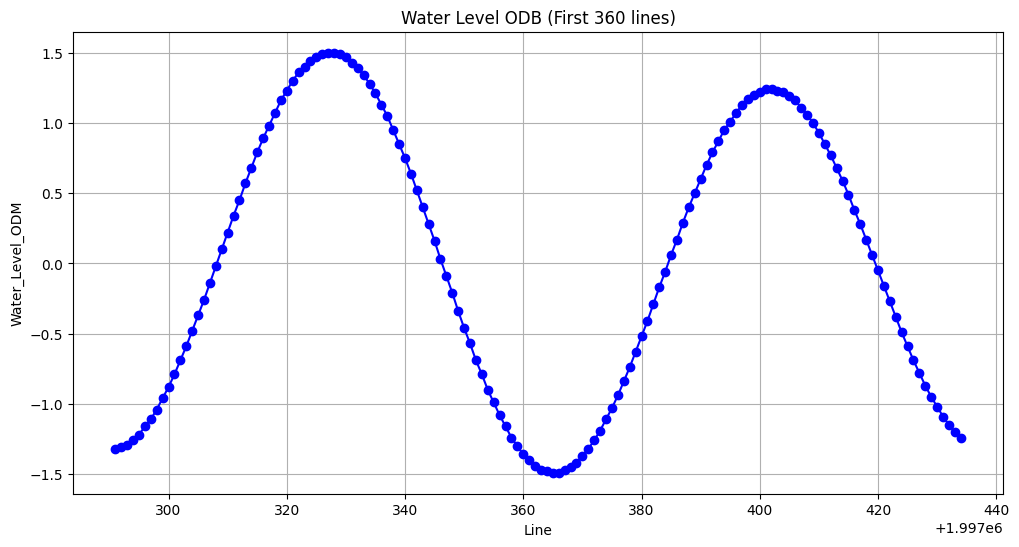

In [38]:
primeras_100 = data_located.head(144)

# This is the water lever over a day, we can see it seems to follow a patern
# This shows perfectly that in a day there are 2 high tides and 2 low tides
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 360 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

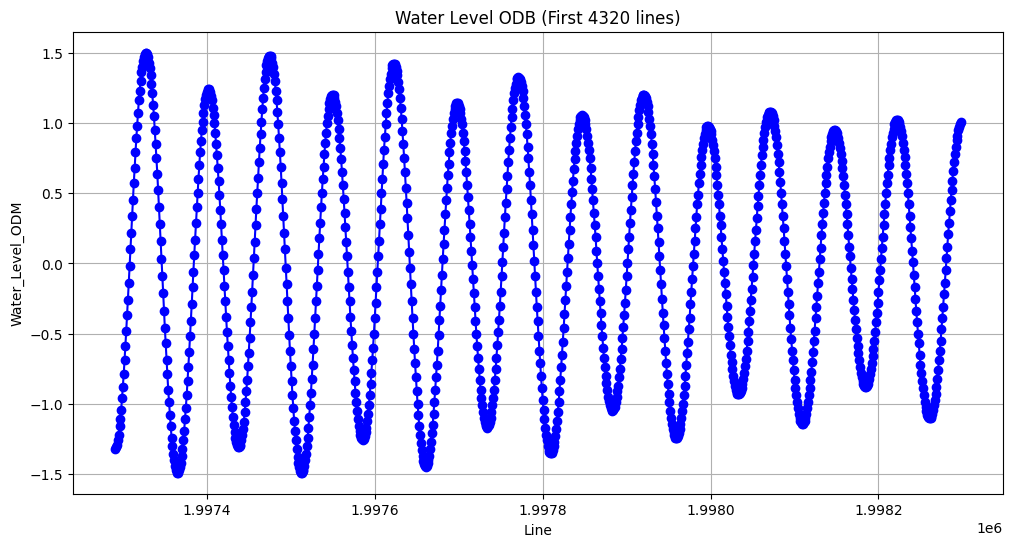

In [39]:
primeras_100 = data_located.head(1008)

# This shows the water level for 1 week, and again it seems to follow a pattern
# The seasonality should be repeated every year, and it should be affected by the season
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 4320 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

## Detecting a random walk

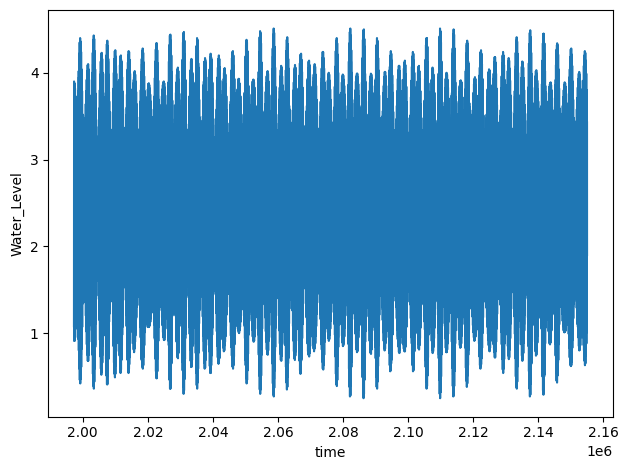

In [40]:
def visualize_time_series(val):
    fig, ax = plt.subplots()
    ax.plot(val)
    ax.set_xlabel('time') # Is just the sequential order
    ax.set_ylabel('Water_Level') # The randomly given value
    plt.tight_layout()

visualize_time_series(data_located['Water_Level'])

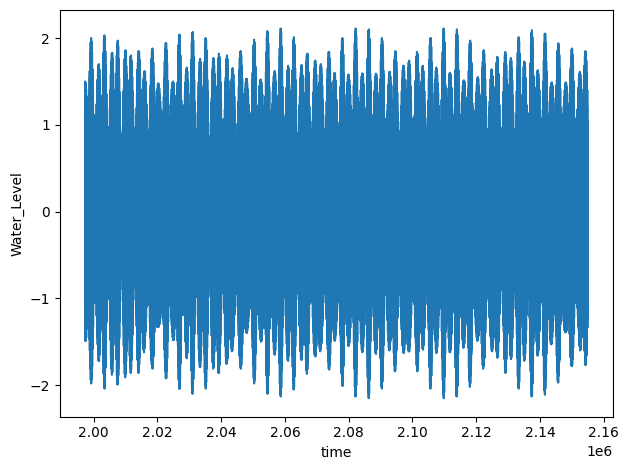

In [41]:
def visualize_time_series(val):
    fig, ax = plt.subplots()
    ax.plot(val)
    ax.set_xlabel('time') # Is just the sequential order
    ax.set_ylabel('Water_Level') # The randomly given value
    plt.tight_layout()

visualize_time_series(data_located['Water_Level_ODM'])

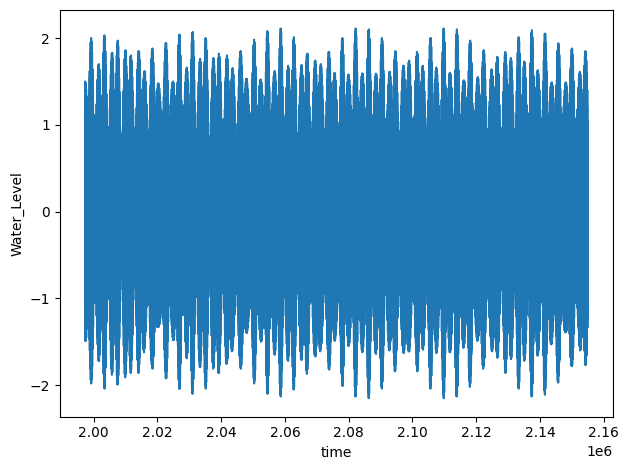

In [ ]:
### Try again by taking only the 2017 data
data_2017 = data_located[data_located['time'].dt.year == 2017]

def visualize_time_series(val):
    fig, ax = plt.subplots()
    ax.plot(val)
    ax.set_xlabel('time') # Is just the sequential order
    ax.set_ylabel('Water_Level') # The randomly given value
    plt.tight_layout()

visualize_time_series(data_2017['Water_Level_ODM'])

In [43]:
# As data is directly a season, the p-value should be 0 or close to 0
# There should be no trend as the season repeatch twice every day
from statsmodels.tsa.stattools import adfuller
ADF_result = adfuller(data_located['Water_Level_ODM'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -104.38192011064093
p-value: 0.0


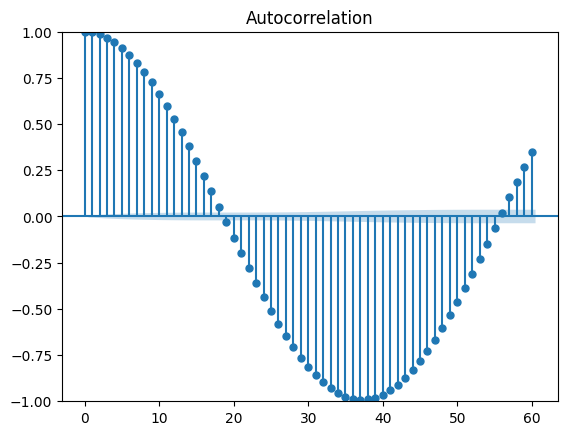

In [44]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data_located['Water_Level_ODM'], lags=60);

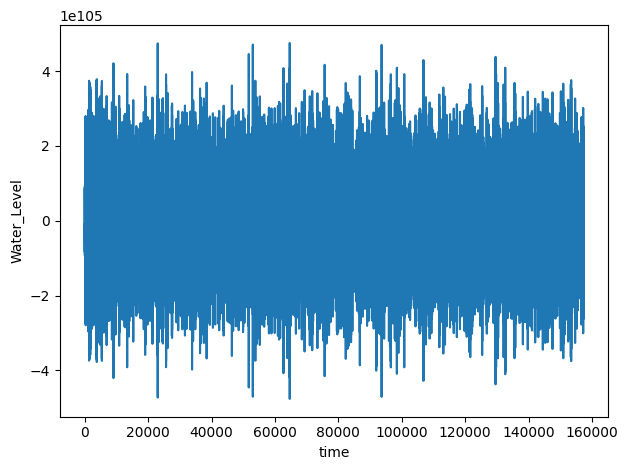

In [45]:
difference = np.diff(data_located['Water_Level_ODM'], n=360)
visualize_time_series(difference)

ADF Statistic: -2938.000308127863
p-value: 0.0


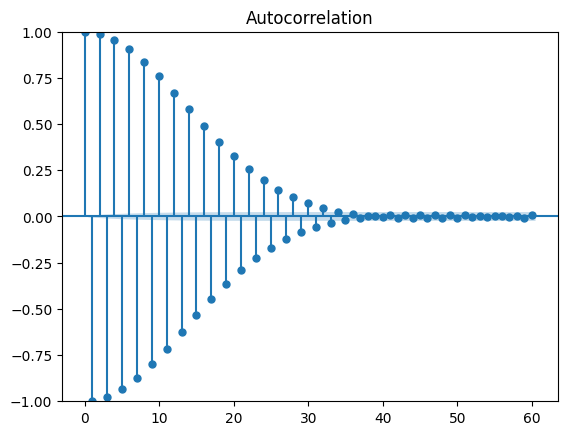

In [46]:
ADF_result = adfuller(difference)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')
plot_acf(difference, lags=60);